In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.cloud import bigquery
from dotenv import load_dotenv

In [2]:
load_dotenv()
client = bigquery.Client()

In [3]:
# Cargamos la tabla analítica que generamos en el Notebook 01
query = "SELECT * FROM `mlopsmarketingproject.olist_marketing_qualified_leads_dataset.abt_marketing_leads`"
df = client.query(query).to_dataframe()

print(f"Dataset cargado: {df.shape} leads listos para análisis estratégico.")

c:\Users\User\Desktop\Software y Clases\BigData\OList\olist-project-sa\.venv\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Dataset cargado: (8000, 11) leads listos para análisis estratégico.


In [4]:
# Agregación por origen de marketing
attribution_df = df.groupby('origin').agg({
    'mql_id': 'count',
    'converted': 'sum',
    'ltv_revenue': 'sum'
}).rename(columns={'mql_id': 'total_leads', 'converted': 'deals_won'})

# Calculamos métricas clave (Efficiency vs Value)
attribution_df['conversion_rate'] = (attribution_df['deals_won'] / attribution_df['total_leads']) * 100
attribution_df['avg_ltv_per_deal'] = attribution_df['ltv_revenue'] / attribution_df['deals_won']

# Ordenar por volumen para la visualización
attribution_df = attribution_df.sort_values('total_leads', ascending=False)

C:\Users\User\AppData\Local\Temp\ipykernel_1960\3954430307.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)


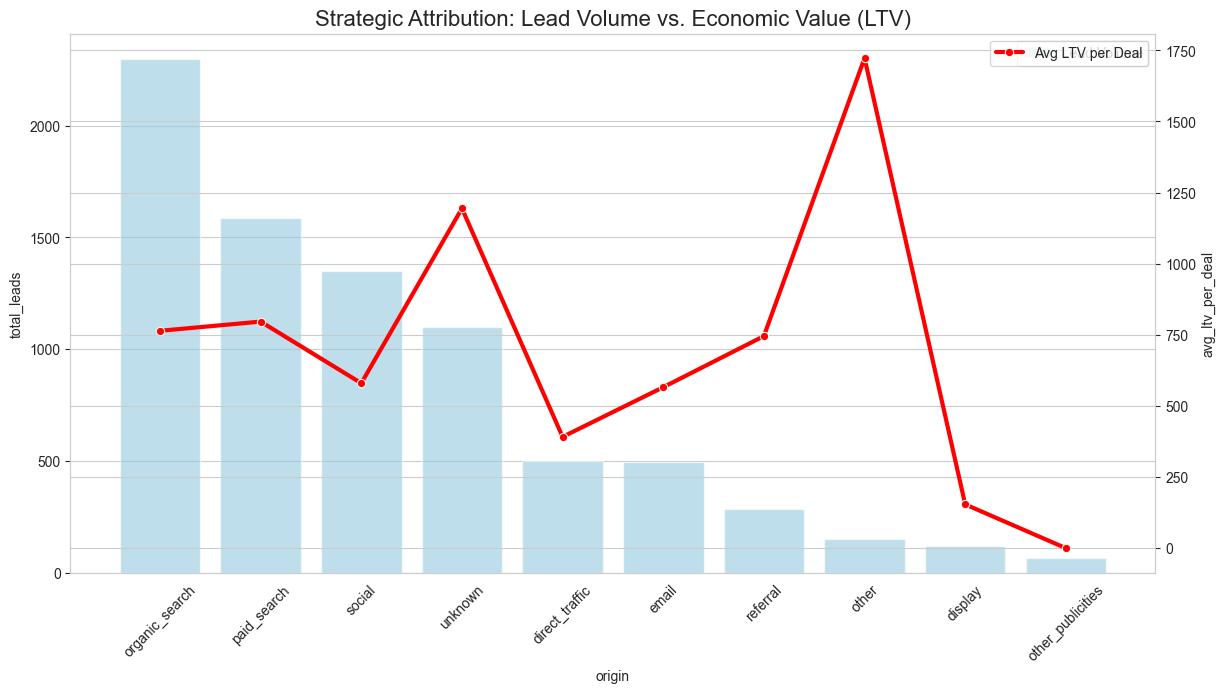

In [5]:
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Gráfico de barras para el volumen de leads
ax1 = sns.barplot(x=attribution_df.index, y=attribution_df['total_leads'], alpha=0.6, color='skyblue', label='Lead Volume')

# Línea para el LTV Promedio
ax2 = ax1.twinx()
sns.lineplot(x=attribution_df.index, y=attribution_df['avg_ltv_per_deal'], marker='o', color='red', linewidth=3, ax=ax2, label='Avg LTV per Deal')

ax1.set_title('Strategic Attribution: Lead Volume vs. Economic Value (LTV)', fontsize=16)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)
plt.show()

Mencionar este insight significativo y hacer Data Forensics

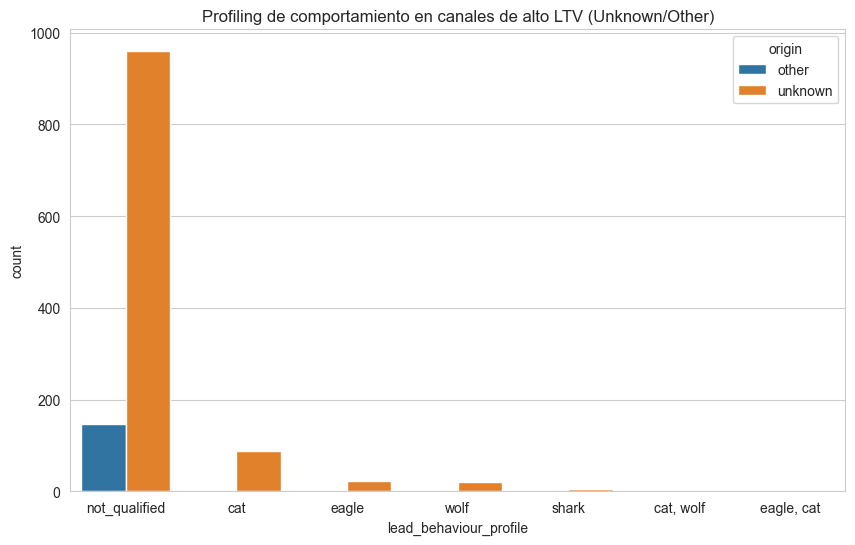

In [6]:
# Analizando el perfil de comportamiento en los canales "misteriosos"
mystery_channels = df[df['origin'].isin(['other', 'unknown'])]

plt.figure(figsize=(10,6))
sns.countplot(data=mystery_channels, x='lead_behaviour_profile', hue='origin')
plt.title('Profiling de comportamiento en canales de alto LTV (Unknown/Other)')
plt.show()

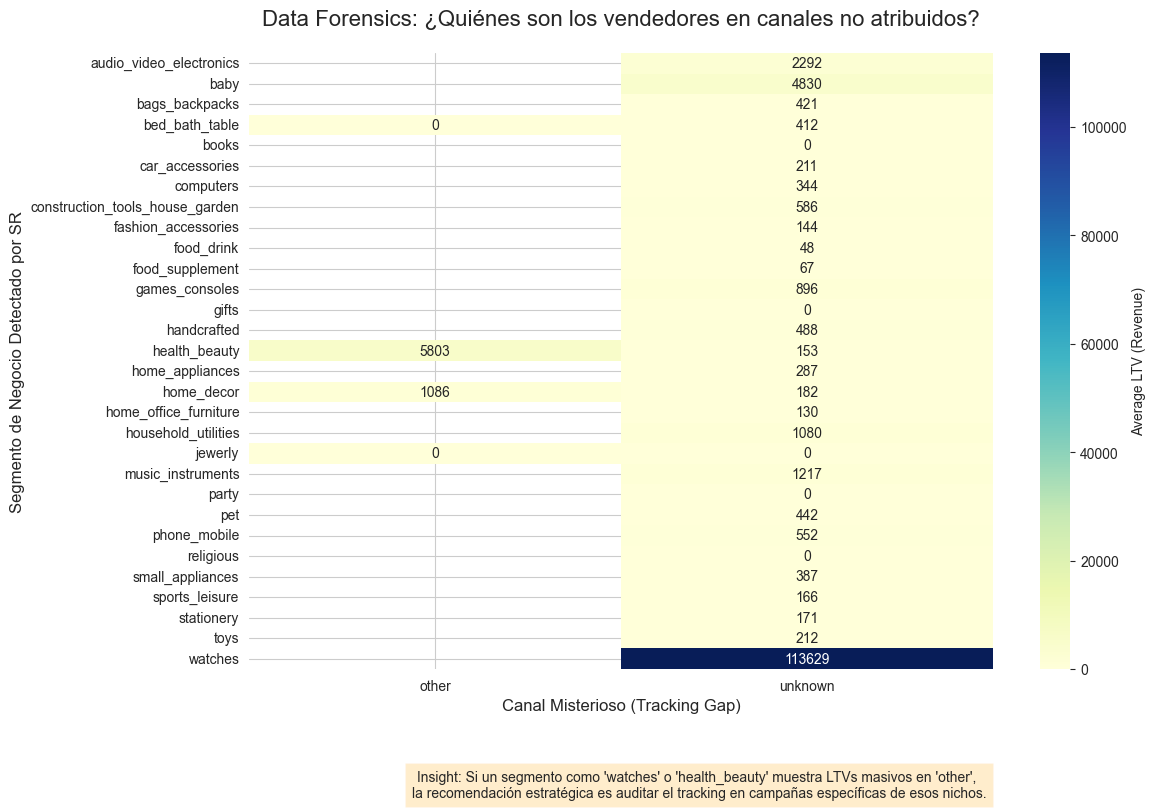

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar para ver solo los canales misteriosos y los segmentos de negocio reales
mask = (df['origin'].isin(['other', 'unknown'])) & (df['business_segment'] != 'not_qualified')
pivot_df = df[mask].pivot_table(
    index='business_segment', 
    columns='origin', 
    values='ltv_revenue', 
    aggfunc='mean'
)

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Average LTV (Revenue)'})

# Storytelling en los labels
plt.title('Data Forensics: ¿Quiénes son los vendedores en canales no atribuidos?', fontsize=16, pad=20)
plt.xlabel('Canal Misterioso (Tracking Gap)', fontsize=12)
plt.ylabel('Segmento de Negocio Detectado por SR', fontsize=12)

# Nota para el reclutador
plt.figtext(0.5, -0.05, 
    "Insight: Si un segmento como 'watches' o 'health_beauty' muestra LTVs masivos en 'other', \n"
    "la recomendación estratégica es auditar el tracking en campañas específicas de esos nichos.", 
    ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})

plt.show()